In [1]:
import pandas as pd
path = "C:/Uner/Semester 5/Multivariat/Coolyeah/Tugas Kelompok 5/archive/arabica_data_cleaned.csv"
df = pd.read_csv(path)
df.shape, df.dtypes
df.head()


,Unnamed: 0,Species,Owner,Country.of.Origin,Farm.Name,Lot.Number,Mill,ICO.Number,Company,Altitude,...,Color,Category.Two.Defects,Expiration,Certification.Body,Certification.Address,Certification.Contact,unit_of_measurement,altitude_low_meters,altitude_high_meters,altitude_mean_meters
0,1,Arabica,metad plc,Ethiopia,metad plc,NaN,metad plc,2014/2015,metad agricultural developmet plc,1950-2200,...,Green,0,"April 3rd, 2016",METAD Agricultural Development plc,309fcf77415a3661ae83e027f7e5f05dad786e44,19fef5a731de2db57d16da10287413f5f99bc2dd,m,1950.0,2200.0,2075.0
1,2,Arabica,metad plc,Ethiopia,metad plc,NaN,metad plc,2014/2015,metad agricultural developmet plc,1950-2200,...,Green,1,"April 3rd, 2016",METAD Agricultural Development plc,309fcf77415a3661ae83e027f7e5f05dad786e44,19fef5a731de2db57d16da10287413f5f99bc2dd,m,1950.0,2200.0,2075.0
2,3,Arabica,grounds for health admin,Guatemala,"san marcos barrancas ""san cristobal cuch",NaN,NaN,NaN,NaN,1600 - 1800 m,...,NaN,0,"May 31st, 2011",Specialty Coffee Association,36d0d00a3724338ba7937c52a378d085f2172daa,0878a7d4b9d35ddbf0fe2ce69a2062cceb45a660,m,1600.0,1800.0,1700.0
3,4,Arabica,yidnekachew dabessa,Ethiopia,yidnekachew dabessa coffee plantation,NaN,wolensu,NaN,yidnekachew debessa coffee plantation,1800-2200,...,Green,2,"March 25th, 2016",METAD Agricultural Development plc,309fcf77415a3661ae83e027f7e5f05dad786e44,19fef5a731de2db57d16da10287413f5f99bc2dd,m,1800.0,2200.0,2000.0
4,5,Arabica,metad plc,Ethiopia,metad plc,NaN,metad plc,2014/2015,metad agricultural developmet plc,1950-2200,...,Green,2,"April 3rd, 2016",METAD Agricultural Development plc,309fcf77415a3661ae83e027f7e5f05dad786e44,19fef5a731de2db57d16da10287413f5f99bc2dd,m,1950.0,2200.0,2075.0


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1311 entries, 0 to 1310
Data columns (total 44 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Unnamed: 0             1311 non-null   int64  
 1   Species                1311 non-null   object 
 2   Owner                  1304 non-null   object 
 3   Country.of.Origin      1310 non-null   object 
 4   Farm.Name              955 non-null    object 
 5   Lot.Number             270 non-null    object 
 6   Mill                   1001 non-null   object 
 7   ICO.Number             1163 non-null   object 
 8   Company                1102 non-null   object 
 9   Altitude               1088 non-null   object 
 10  Region                 1254 non-null   object 
 11  Producer               1081 non-null   object 
 12  Number.of.Bags         1311 non-null   int64  
 13  Bag.Weight             1311 non-null   object 
 14  In.Country.Partner     1311 non-null   object 
 15  Harv

In [3]:
# missing summary
df.isna().sum()

# drop rows with >50% missing
df = df[df.isnull().mean(axis=1) < 0.5].copy()

# simple imputation median for numeric
num_cols = df.select_dtypes(include='number').columns
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

# drop duplicates
df = df.drop_duplicates()


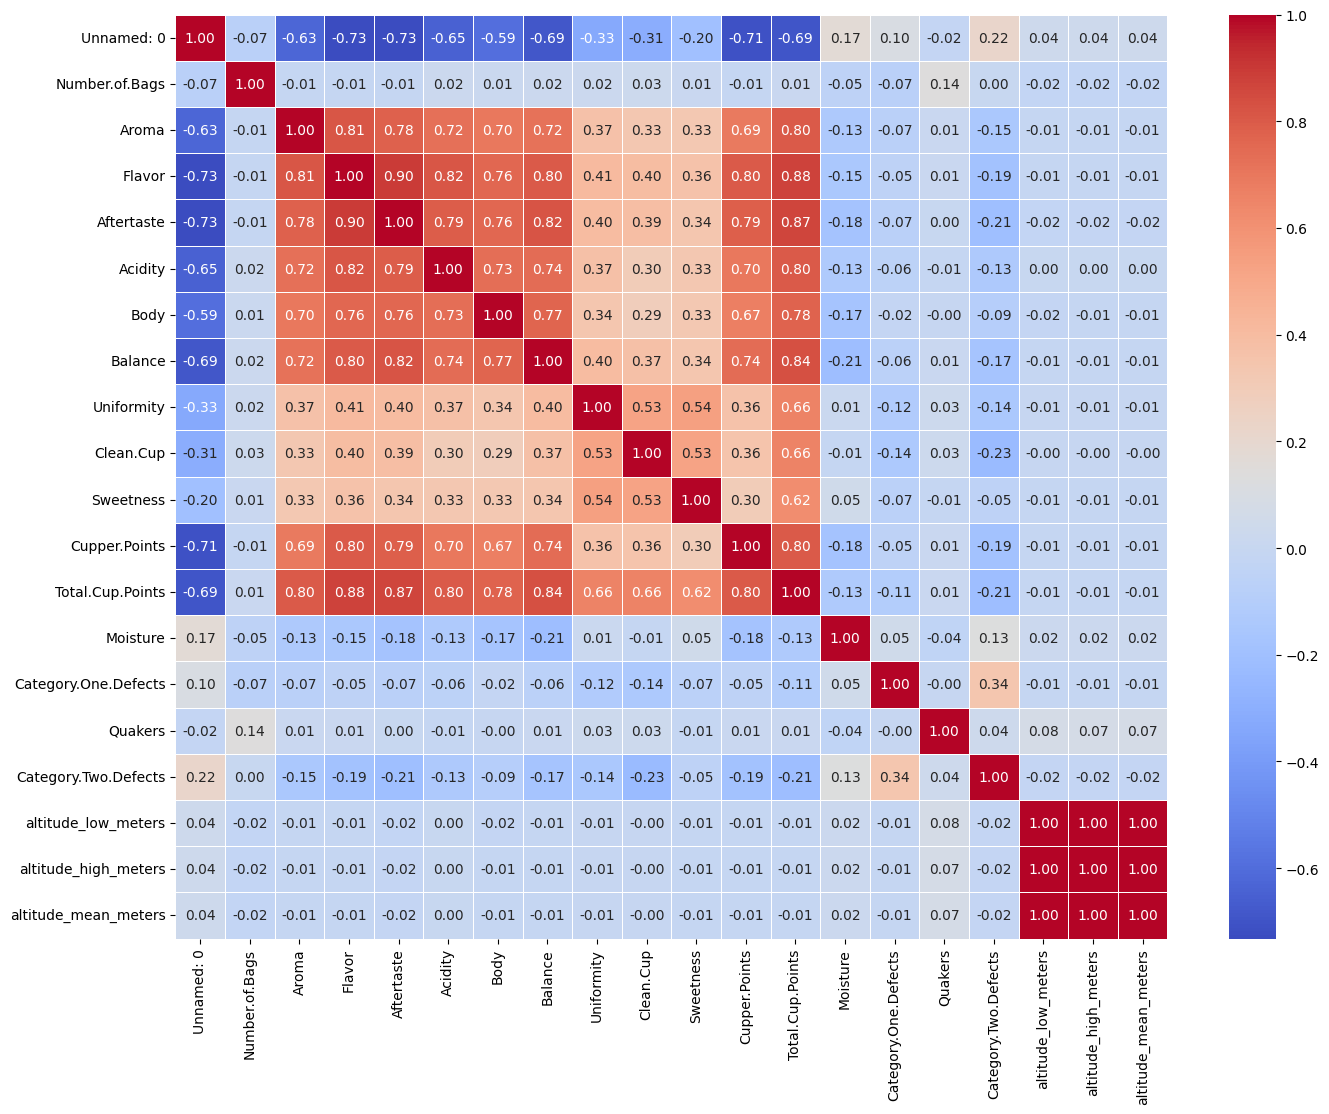

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Atur ukuran canvas (figure) agar lebih besar
plt.figure(figsize=(16, 12)) 

# 2. Buat heatmap dengan parameter tambahan untuk keterbacaan
sns.heatmap(
    df[num_cols].corr(), 
    annot=True,           # Menampilkan angka korelasi
    fmt=".2f",            # Format angka 2 desimal
    cmap='coolwarm',      # (Opsional) Warna kontras biru-merah agar lebih enak dilihat
    linewidths=0.5,       # Memberi jarak/garis putih antar kotak
    annot_kws={"size": 10} # Mengatur ukuran font angka di dalam kotak
)

# 3. Tampilkan plot
plt.show()

In [5]:
from sklearn.preprocessing import StandardScaler
X = df[num_cols].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [6]:
import numpy as np
from scipy.spatial.distance import mahalanobis

cov = np.cov(X_scaled, rowvar=False)
inv_cov = np.linalg.inv(cov)
mean = X_scaled.mean(axis=0)
md = [mahalanobis(x, mean, inv_cov) for x in X_scaled]
df['mahalanobis'] = md
df.sort_values('mahalanobis', ascending=False).head(10)


,Unnamed: 0,Species,Owner,Country.of.Origin,Farm.Name,Lot.Number,Mill,ICO.Number,Company,Altitude,...,Category.Two.Defects,Expiration,Certification.Body,Certification.Address,Certification.Contact,unit_of_measurement,altitude_low_meters,altitude_high_meters,altitude_mean_meters,mahalanobis
1310,1312,Arabica,bismarck castro,Honduras,los hicaques,103,cigrah s.a de c.v.,13-111-053,cigrah s.a de c.v,1400,...,2,"April 28th, 2018",Instituto Hondureño del Café,b4660a57e9f8cc613ae5b8f02bfce8634c763ab4,7f521ca403540f81ec99daec7da19c2788393880,m,1400.00,1400.00,1400.00,32.537282
1229,1230,Arabica,pablo cervantes morelos,Mexico,llano hermoso,NaN,"llano hermoso, xochitonalco huautla, oaxaca",0,asociación agricola local de productores de ca...,1300,...,47,"September 11th, 2013",AMECAFE,3e18a5ae6f5e2aabca37e025f94e1974558bf5f0,e3212d17882b7657b3fba559b4072e552604d5d1,m,1300.00,1300.00,1300.00,31.339665
628,629,Arabica,george a. fernandez,Colombia,la canada,NaN,the beneficio is designed to be ecologic,2889,NaN,1800 meters (5900,...,0,"November 15th, 2012",Specialty Coffee Association,36d0d00a3724338ba7937c52a378d085f2172daa,0878a7d4b9d35ddbf0fe2ce69a2062cceb45a660,m,1800.00,5900.00,3850.00,23.954726
1144,1145,Arabica,juan luis alvarado romero,Guatemala,la esperanza,11/23/0507,beneficio ixchel,11/23/0507,"unex guatemala, s.a.",1901.64,...,1,"June 22nd, 2018",Asociacion Nacional Del Café,b1f20fe3a819fd6b2ee0eb8fdc3da256604f1e53,724f04ad10ed31dbb9d260f0dfd221ba48be8a95,m,190164.00,190164.00,190164.00,23.882390
896,897,Arabica,juan luis alvarado romero,Guatemala,la esperanza,11/23/0368,beneficio ixchel,11/23/0368,"unex guatemala, s.a.",190164,...,0,"June 1st, 2018",Asociacion Nacional Del Café,b1f20fe3a819fd6b2ee0eb8fdc3da256604f1e53,724f04ad10ed31dbb9d260f0dfd221ba48be8a95,m,190164.00,190164.00,190164.00,23.769766
536,537,Arabica,"lin, che-hao krude 林哲豪",Taiwan,shi fang yuan 十方源,2016 Tainan Coffee Cupping Event Micro Lot 臺南市...,shi fang yuan 十方源,Taiwan,taiwan coffee laboratory,350,...,0,"June 28th, 2017",Specialty Coffee Association,36d0d00a3724338ba7937c52a378d085f2172daa,0878a7d4b9d35ddbf0fe2ce69a2062cceb45a660,m,350.00,350.00,350.00,19.730966
1309,1310,Arabica,juan luis alvarado romero,Guatemala,finca el limon,NaN,beneficio serben,11/853/165,unicafe,4650,...,4,"May 24th, 2013",Asociacion Nacional Del Café,b1f20fe3a819fd6b2ee0eb8fdc3da256604f1e53,724f04ad10ed31dbb9d260f0dfd221ba48be8a95,ft,1417.32,1417.32,1417.32,19.690303
1306,1307,Arabica,juan carlos garcia lopez,Mexico,el centenario,NaN,"la esperanza, municipio juchique de ferrer, ve...",1104328663,terra mia,900,...,20,"September 17th, 2013",AMECAFE,59e396ad6e22a1c22b248f958e1da2bd8af85272,0eb4ee5b3f47b20b049548a2fd1e7d4a2b70d0a7,m,900.00,900.00,900.00,16.541917
1040,1041,Arabica,"comercial internacional exportadora, s.a.",Nicaragua,cafetales santa matilde,NaN,beneficio san carlos,017/001/1066,"comercial internacional exportadora, s.a.",1100.00 mosl,...,5,"May 27th, 2016",Asociación de Cafés Especiales de Nicaragua,fc561dd3c2eee024b032933e0a97b4aede0dc206,f79a8d4dee92a80ff14025f03ea34fa316b2132f,m,110000.00,110000.00,110000.00,13.802790
1279,1280,Arabica,martin jimenez casiano,Mexico,peña campana,NaN,peña campana,3,union regional de cafeticultores de la mazatec...,1280,...,29,"March 5th, 2013",AMECAFE,59e396ad6e22a1c22b248f958e1da2bd8af85272,0eb4ee5b3f47b20b049548a2fd1e7d4a2b70d0a7,m,1280.00,1280.00,1280.00,13.736479


In [7]:
from sklearn.metrics import pairwise_distances
D_euclid = pairwise_distances(X_scaled, metric='euclidean')
D_corr = pairwise_distances(X_scaled, metric='correlation')  # returns 1 - corr


In [8]:
from sklearn.manifold import MDS

mds_metric = MDS(n_components=2, metric=True, dissimilarity='precomputed', random_state=42, n_init=10, max_iter=300)
coords_metric = mds_metric.fit_transform(D_euclid)
stress_metric = mds_metric.stress_

mds_nmetric = MDS(n_components=2, metric=False, dissimilarity='precomputed', random_state=42, n_init=10, max_iter=300)
coords_nmetric = mds_nmetric.fit_transform(D_euclid)
stress_nmetric = mds_nmetric.stress_


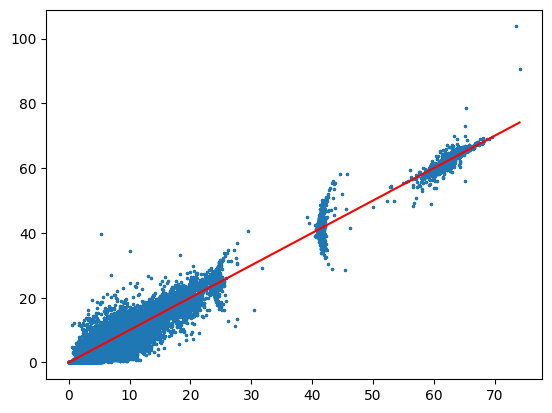

In [9]:
import matplotlib.pyplot as plt
from sklearn.metrics import euclidean_distances
fitted_d = euclidean_distances(coords_metric)
orig_d = D_euclid
plt.scatter(orig_d.flatten(), fitted_d.flatten(), s=2)
plt.plot([orig_d.min(), orig_d.max()], [orig_d.min(), orig_d.max()], color='red')


In [11]:
import numpy as np
corrs = np.corrcoef(X_scaled.T, coords_metric.T)[:len(num_cols), len(num_cols):]
# corrs shape: (n_vars, 2)


In [12]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
for k in range(2,7):
    km = KMeans(n_clusters=k, random_state=42).fit(coords_metric)
    print(k, silhouette_score(coords_metric, km.labels_))


2 0.9276100427992929
3 0.28548916807611247
4 0.2808245204509537
5 0.3127804115552915
6 0.34701132109726324


In [14]:
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import pairwise_distances, silhouette_score
from sklearn.manifold import MDS
from sklearn.cluster import KMeans
from scipy.spatial.distance import mahalanobis
from scipy.spatial import procrustes
from numpy.linalg import inv, eigh

# Optional imports (Mantel / PERMANOVA)
try:
    from skbio.stats.distance import permanova, DistanceMatrix
    from skbio.stats.distance import mantel
    SKBIO_AVAILABLE = True
except Exception:
    SKBIO_AVAILABLE = False

# -------------------- USER CONFIG --------------------
DATA_PATH = "C:/Uner/Semester 5/Multivariat/Coolyeah/Tugas Kelompok 5/dataset/arabica_data_cleaned.csv"
OUT_DIR = "C:/Uner/Semester 5/Multivariat/Coolyeah/Tugas Kelompok 5/output"
os.makedirs(OUT_DIR, exist_ok=True)

# Variables selection override: leave as None to auto-detect common sensory columns
# Example: selected_vars = ['Aroma','Flavor','Aftertaste','Sweetness','Body','Balance','Uniformity','Moisture']
selected_vars = None

# MDS / bootstrap config
NON_METRIC_SUBSET = 300   # set None to skip NMDS; smaller reduces time
BOOTSTRAP_N = 40          # number of bootstrap resamples (lower = faster)
RANDOM_STATE = 42
# -----------------------------------------------------

np.random.seed(RANDOM_STATE)

def load_data(path):
    print("Loading:", path)
    df = pd.read_csv(path)
    print("Shape:", df.shape)
    return df

def auto_select_vars(df):
    lower_cols = [c.lower() for c in df.columns]
    # candidate numeric columns
    nums = df.select_dtypes(include=[np.number]).columns.tolist()
    # remove obvious non-feature numeric columns
    drop_tokens = ['id','name','url','link','review','date','rating','score_text','notes','producer']
    nums = [c for c in nums if not any(tok in c.lower() for tok in drop_tokens)]
    # prefer common cupping attributes if present (in order)
    preferred = ['aroma','acidity','flavor','aftertaste','sweetness','body','balance','uniformity','clean_cup','overall','moisture','total_cup_points']
    found = [p for p in preferred if p in lower_cols]
    if found:
        found_actual = [df.columns[lower_cols.index(p)] for p in found]
        selected = [c for c in found_actual if c in nums]
        print("Auto-detected sensory columns (preferred):", selected)
        return selected
    # fallback: pick top numeric vars with >5 unique values
    nums = [c for c in nums if df[c].nunique() > 5]
    selected = nums[:12]
    print("Auto-detected numeric columns (fallback):", selected)
    return selected

def preprocess(df, vars_list):
    X = df[vars_list].copy()
    # drop rows with >50% missing in selected vars
    thresh = int(len(vars_list) * 0.5)
    keep_mask = X.isna().sum(axis=1) <= thresh
    dropped = (~keep_mask).sum()
    if dropped:
        print(f"Dropping {dropped} rows with >50% missing in selected vars.")
    X = X[keep_mask].copy()
    meta = df.loc[X.index].copy()
    # median impute remaining missing
    X = X.fillna(X.median())
    # standardize (z-score)
    scaler = StandardScaler()
    Xs = scaler.fit_transform(X.values)
    return X, Xs, meta, scaler

def save_descriptives(X, outdir):
    desc = X.describe().T
    desc.to_csv(os.path.join(outdir, "desc_selected_vars.csv"))
    return desc

def plot_corr_heatmap(Xs, vars_list, outdir):
    corr = pd.DataFrame(Xs, columns=vars_list).corr()
    plt.figure(figsize=(8,6))
    sns.heatmap(corr, annot=True, fmt=".2f", cmap='vlag', center=0)
    plt.title("Correlation (standardized selected vars)")
    plt.tight_layout()
    path = os.path.join(outdir, "correlation_selected_vars.png")
    plt.savefig(path, dpi=150); plt.close()
    return path, corr

def mahalanobis_outliers(Xs, meta, outdir, percentile=97.5):
    cov = np.cov(Xs, rowvar=False)
    invcov = inv(cov)
    mean_vec = Xs.mean(axis=0)
    md = np.array([mahalanobis(row, mean_vec, invcov) for row in Xs])
    meta = meta.copy()
    meta['mahalanobis'] = md
    thr = np.percentile(md, percentile)
    meta['is_outlier'] = meta['mahalanobis'] > thr
    out_path = os.path.join(outdir, "mahalanobis_outliers.csv")
    meta.sort_values('mahalanobis', ascending=False).to_csv(out_path)
    return meta, thr, out_path

def classical_mds(D, n_components=2):
    """
    Classical (Torgerson) MDS via eigendecomposition of double-centered matrix.
    D: pairwise distance matrix (n x n)
    """
    n = D.shape[0]
    D2 = D**2
    J = np.eye(n) - np.ones((n,n))/n
    B = -0.5 * J.dot(D2).dot(J)
    eigvals, eigvecs = eigh(B)
    idx = np.argsort(eigvals)[::-1]
    eigvals = eigvals[idx]
    eigvecs = eigvecs[:, idx]
    pos = eigvals > 0
    k = min(n_components, np.sum(pos))
    if k <= 0:
        raise ValueError("No positive eigenvalues found; cannot form classical MDS embedding.")
    L = np.diag(np.sqrt(eigvals[:k]))
    V = eigvecs[:, :k]
    Y = V.dot(L)
    if k < n_components:
        Y = np.hstack([Y, np.zeros((n, n_components-k))])
    return Y

def compute_stress(D_orig, coords):
    fitted = pairwise_distances(coords, metric='euclidean')
    num = np.sum((D_orig - fitted)**2)
    den = np.sum(D_orig**2)
    return num/den

def plot_mds_scatter(coords, meta, color_by, title, fname, outdir):
    plt.figure(figsize=(10,8))
    if color_by is not None and color_by in meta.columns:
        sns.scatterplot(x=coords[:,0], y=coords[:,1], hue=meta[color_by], palette='tab10', s=40, alpha=0.8, edgecolor='k')
        plt.legend(bbox_to_anchor=(1.05,1), loc='upper left', title=color_by)
    else:
        plt.scatter(coords[:,0], coords[:,1], s=30)
    plt.xlabel("MDS1"); plt.ylabel("MDS2"); plt.title(title)
    plt.grid(True, linestyle='--', alpha=0.3)
    plt.tight_layout()
    path = os.path.join(outdir, fname)
    plt.savefig(path, dpi=150); plt.close()
    return path

def shepard_plot(D_orig, coords, fname, outdir):
    fitted = pairwise_distances(coords, metric='euclidean')
    plt.figure(figsize=(6,5))
    plt.scatter(D_orig.flatten(), fitted.flatten(), s=6, alpha=0.5)
    mn, mx = D_orig.min(), D_orig.max()
    plt.plot([mn,mx],[mn,mx], color='red', linewidth=1)
    plt.xlabel("Original dissimilarities"); plt.ylabel("Fitted distances"); plt.title("Shepard plot")
    plt.tight_layout()
    path = os.path.join(outdir, fname)
    plt.savefig(path, dpi=150); plt.close()
    return path

def biplot_vars(Xs, coords, vars_list, outdir, scale=3.0):
    corrs = np.corrcoef(Xs.T, coords.T)[:len(vars_list), len(vars_list):]
    corr_df = pd.DataFrame(corrs, index=vars_list, columns=['MDS1','MDS2'])
    corr_df.to_csv(os.path.join(outdir, "variable_coord_correlations.csv"))
    # plot
    plt.figure(figsize=(10,8))
    plt.scatter(coords[:,0], coords[:,1], s=30, alpha=0.7)
    for i,var in enumerate(vars_list):
        xvec = corrs[i,0]*scale; yvec = corrs[i,1]*scale
        plt.arrow(0,0, xvec, yvec, head_width=0.05, head_length=0.07, color='red', linewidth=1.2)
        plt.text(xvec*1.12, yvec*1.12, var, color='red', fontsize=10)
    plt.xlabel("MDS1"); plt.ylabel("MDS2"); plt.title("Biplot (variables as correlation vectors)")
    plt.grid(True, linestyle='--', alpha=0.3)
    plt.tight_layout()
    path = os.path.join(outdir, "mds_biplot.png")
    plt.savefig(path, dpi=150); plt.close()
    return path, corr_df

def clustering_on_coords(coords, meta, outdir, k_min=2, k_max=6):
    best_k = None; best_score = -1; best_labels = None
    for k in range(k_min, k_max+1):
        km = KMeans(n_clusters=k, random_state=RANDOM_STATE).fit(coords)
        sc = silhouette_score(coords, km.labels_)
        print(f"k={k}, silhouette={sc:.4f}")
        if sc > best_score:
            best_score = sc; best_k = k; best_labels = km.labels_
    meta = meta.copy()
    meta['cluster'] = best_labels
    sizes = meta['cluster'].value_counts().sort_index()
    sizes.to_csv(os.path.join(outdir, "cluster_sizes.csv"), header=['count'])
    # cluster profiles (means)
    cluster_profiles = pd.DataFrame(X, index=meta.index).join(meta['cluster']).groupby('cluster').mean()
    cluster_profiles.to_csv(os.path.join(outdir, "cluster_profiles.csv"))
    return meta, best_k, best_score, cluster_profiles

def nmds_on_subset(D, subset_n=300, random_state=RANDOM_STATE):
    if subset_n is None:
        return None, None, None
    n = D.shape[0]
    subset_n = min(subset_n, n)
    rng = np.random.RandomState(random_state)
    idx = rng.choice(np.arange(n), size=subset_n, replace=False)
    D_sub = D[np.ix_(idx, idx)]
    print(f"Running non-metric MDS on subset (n={subset_n}) — may take time")
    mds_nm = MDS(n_components=2, metric=False, dissimilarity='precomputed', random_state=random_state, n_init=4, max_iter=400)
    coords_sub = mds_nm.fit_transform(D_sub)
    return idx, coords_sub, mds_nm

def bootstrap_coords_procrustes(Xs, coords_ref, n_boot=40, outdir=None):
    """
    Bootstrap by resampling rows with replacement.
    For each bootstrap sample, compute classical MDS coords, then align (Procrustes)
    the bootstrap coords to coords_ref using the shared sampled points, and record aligned coords
    for the indices present in the sample. Finally compute SD per original sample across boots.
    Note: mapping via first occurrence; approximate but informative.
    """
    n = Xs.shape[0]
    coords_boot_all = np.full((n_boot, n, 2), np.nan)
    rng = np.random.RandomState(RANDOM_STATE)
    for b in range(n_boot):
        idx = rng.choice(np.arange(n), size=n, replace=True)
        # distance and MDS on the sampled set
        D_b = pairwise_distances(Xs[idx,:], metric='euclidean')
        coords_b = classical_mds(D_b, n_components=2)
        # find mapping from original index -> first occurrence position in idx
        inv_map = {}
        for pos, orig in enumerate(idx):
            if orig not in inv_map:
                inv_map[orig] = pos
        # build matrices of matched points between coords_ref and coords_b (for those orig present)
        matched_orig = sorted(inv_map.keys())
        if len(matched_orig) < 3:
            # too few points to align; skip this bootstrap
            continue
        A = coords_ref[matched_orig, :]  # reference coords for these original samples
        B = coords_b[[inv_map[o] for o in matched_orig], :]
        try:
            mtx1, mtx2, disparity = procrustes(A, B)
            # mtx2 corresponds to B transformed to best fit A
            # assign aligned coords back to original indices
            for i, orig in enumerate(matched_orig):
                coords_boot_all[b, orig, :] = mtx2[i, :]
        except Exception:
            # procrustes may fail in degenerate cases
            for orig, pos in inv_map.items():
                coords_boot_all[b, orig, :] = coords_b[pos, :]
    # compute SD across boots (ignoring NaNs)
    sd_coords = np.nanstd(coords_boot_all, axis=0)
    sd_mean = np.nanmean(sd_coords, axis=1)
    if outdir:
        # save per-sample stds
        df_sd = pd.DataFrame(sd_coords, columns=['sd_MDS1','sd_MDS2'])
        df_sd['sd_mean'] = sd_mean
        df_sd.to_csv(os.path.join(outdir, "bootstrap_coord_std_per_sample.csv"), index=False)
    return sd_mean

# -------------------- MAIN PIPELINE --------------------
if __name__ == "__main__":
    # 1. Load
    df = load_data(DATA_PATH)

    # 2. Select variables
    if selected_vars is None:
        vars_list = auto_select_vars(df)
    else:
        vars_list = selected_vars
    if len(vars_list) < 3:
        raise ValueError("Need at least 3 numeric vars for meaningful MDS. Update selected_vars.")

    # 3. Preprocess
    X, Xs, meta, scaler = preprocess(df, vars_list)
    # add index column for traceability
    meta = meta.copy()
    meta.reset_index(inplace=True)  # keep original index a column named 'index'
    meta = meta.set_index('index', drop=False)

    # 4. Descriptives & correlation heatmap
    desc = save_descriptives(X, OUT_DIR)
    heatmap_path, corr = plot_corr_heatmap(Xs, vars_list, OUT_DIR)
    print("Saved correlation heatmap:", heatmap_path)

    # 5. Mahalanobis outliers
    meta, md_thr, outliers_path = mahalanobis_outliers(Xs, meta, OUT_DIR)
    print("Saved Mahalanobis outlier table:", outliers_path, "| threshold:", md_thr)

    # 6. Distances & classical MDS (metric)
    D = pairwise_distances(Xs, metric='euclidean')
    t0 = time.time()
    coords_metric = classical_mds(D, n_components=2)
    t1 = time.time()
    print(f"Classical MDS computed in {t1-t0:.2f}s")
    stress_metric = compute_stress(D, coords_metric)
    print("Metric (classical) normalized stress:", stress_metric)

    # add coords to meta and save
    meta['MDS1'] = coords_metric[:,0]
    meta['MDS2'] = coords_metric[:,1]
    meta.to_csv(os.path.join(OUT_DIR, "arabica_analysis_meta_precluster.csv"))

    # 7. Save metric scatter colored by origin if present
    color_col = None
    # heuristic: common origin columns
    for cand in ['Country.of.Origin','Country','country','origin']:
        if cand in meta.columns:
            color_col = cand; break
    s_path = plot_mds_scatter(coords_metric, meta, color_col, f"Classical MDS (metric) — normalized stress {stress_metric:.4f}", "mds_metric_scatter.png", OUT_DIR)
    print("Saved MDS scatter:", s_path)

    # 8. Shepard plot
    s_plot = shepard_plot(D, coords_metric, "shepard_metric.png", OUT_DIR)
    print("Saved Shepard plot:", s_plot)

    # 9. Biplot
    biplot_path, corr_df = biplot_vars(Xs, coords_metric, vars_list, OUT_DIR)
    print("Saved biplot and correlations:", biplot_path, os.path.join(OUT_DIR,"variable_coord_correlations.csv"))

    # 10. Clustering on coords
    meta, best_k, best_score, cluster_profiles = clustering_on_coords(coords_metric, meta, OUT_DIR)
    print(f"Best k by silhouette: {best_k} (score {best_score:.4f})")
    # cluster scatter
    cs_path = plot_mds_scatter(coords_metric, meta, 'cluster', f"MDS by cluster (k={best_k})", "mds_clusters.png", OUT_DIR)
    print("Saved cluster scatter:", cs_path)

    # 11. Non-metric MDS on subset (optional)
    if NON_METRIC_SUBSET:
        try:
            subset_idx, coords_sub, nm_obj = nmds_on_subset(D, NON_METRIC_SUBSET)
            # save image for subset: plot coords_sub colored by origin if available
            plt.figure(figsize=(8,6))
            if color_col is not None:
                sns.scatterplot(x=coords_sub[:,0], y=coords_sub[:,1], hue=meta.iloc[subset_idx][color_col], palette='tab10', s=40, alpha=0.8)
                plt.legend(bbox_to_anchor=(1.05,1), loc='upper left')
            else:
                plt.scatter(coords_sub[:,0], coords_sub[:,1], s=30)
            plt.title("Non-metric MDS (subset)")
            plt.xlabel("NMDS1"); plt.ylabel("NMDS2")
            plt.tight_layout(); plt.savefig(os.path.join(OUT_DIR, "nmds_subset.png"), dpi=150); plt.close()
            print("Saved non-metric subset MDS: nmds_subset.png")
        except Exception as e:
            print("Non-metric MDS failed on subset:", str(e))
    else:
        print("Skipping non-metric MDS (NON_METRIC_SUBSET set to None or 0).")

    # 12. Bootstrap coordinate stability (approx with Procrustes alignment)
    print("Running bootstrap coordinate stability (n_boot=", BOOTSTRAP_N, ") — may take some time.")
    sd_mean = bootstrap_coords_procrustes(Xs, coords_metric, n_boot=BOOTSTRAP_N, outdir=OUT_DIR)
    meta['boot_coord_std'] = sd_mean
    # save meta with diagnostics
    meta.to_csv(os.path.join(OUT_DIR, "arabica_analysis_meta.csv"))
    print("Saved meta diagnostics to arabica_analysis_meta.csv")

    # Save bootstrap uncertainty plot (marker size ~ sd_mean)
    plt.figure(figsize=(10,8))
    sizes = 20 + 200 * (meta['boot_coord_std'] / (np.nanmax(meta['boot_coord_std']) + 1e-9))
    cmap = 'viridis'
    plt.scatter(coords_metric[:,0], coords_metric[:,1], s=sizes, c=meta['cluster'], cmap='Set2', alpha=0.8, edgecolor='k')
    plt.title("MDS scatter (marker size ~ bootstrap coord std)")
    plt.xlabel("MDS1"); plt.ylabel("MDS2")
    plt.tight_layout(); plt.savefig(os.path.join(OUT_DIR, "mds_bootstrap_uncertainty.png"), dpi=150); plt.close()
    print("Saved bootstrap uncertainty plot.")

    # 13. Relationship with overall score if present
    score_col = None
    lower_cols = [c.lower() for c in df.columns]
    for cand in ['overall','total_cup_points','score','total_score','quality_score']:
        if cand in lower_cols:
            score_col = df.columns[lower_cols.index(cand)]
            break
    if score_col:
        meta['score'] = df.loc[meta.index, score_col]
        # scatter colored by score
        plt.figure(figsize=(10,8))
        sc = plt.scatter(coords_metric[:,0], coords_metric[:,1], c=meta['score'], cmap='viridis', s=50, edgecolor='k')
        plt.colorbar(sc, label='Overall score')
        plt.title("MDS colored by overall score")
        plt.xlabel("MDS1"); plt.ylabel("MDS2")
        plt.tight_layout(); plt.savefig(os.path.join(OUT_DIR, "mds_colored_by_score.png"), dpi=150); plt.close()
        print("Saved MDS colored by score.")
        # correlations score vs MDS axes
        r1 = np.corrcoef(meta['score'], meta['MDS1'])[0,1]
        r2 = np.corrcoef(meta['score'], meta['MDS2'])[0,1]
        print(f"Correlation score vs MDS1: {r1:.3f}, score vs MDS2: {r2:.3f}")
    else:
        print("No overall/score column auto-detected (rename your score column to include 'overall' or 'total_cup_points' to auto-detect).")

    # 14. Optional Mantel & PERMANOVA (requires scikit-bio)
    if SKBIO_AVAILABLE:
        try:
            dm = DistanceMatrix(D)
            # Mantel: D vs distances in MDS space
            fitted = pairwise_distances(coords_metric, metric='euclidean')
            dm_fitted = DistanceMatrix(fitted)
            mantel_res = mantel(dm, dm_fitted, permutations=999)
            print("Mantel test (D vs fitted): r:", mantel_res[0], "p-value:", mantel_res[2])
            with open(os.path.join(OUT_DIR, "mantel_result.txt"), 'w') as f:
                f.write(str(mantel_res))
            # PERMANOVA by Country if column exists
            if color_col is not None:
                grouping = meta[color_col]
                permanova_res = permanova(dm, grouping, permutations=999)
                print("PERMANOVA by", color_col, ":", permanova_res)
                with open(os.path.join(OUT_DIR, "permanova_result.txt"), 'w') as f:
                    f.write(str(permanova_res))
        except Exception as e:
            print("Mantel / PERMANOVA failed:", str(e))
    else:
        print("scikit-bio not available; skipping Mantel and PERMANOVA (optional).")

    # 15. Summary outputs
    print("\n--- ANALYSIS COMPLETE ---")
    print("Output folder:", OUT_DIR)
    print("Key files produced:")
    for fname in ["correlation_selected_vars.png","mahalanobis_outliers.csv","arabica_analysis_meta.csv",
                  "mds_metric_scatter.png","shepard_metric.png","mds_biplot.png","cluster_profiles.csv",
                  "mds_clusters.png","mds_bootstrap_uncertainty.png","variable_coord_correlations.csv"]:
        path = os.path.join(OUT_DIR, fname)
        if os.path.exists(path):
            print(" -", path)
    print("If you want, share the following files and I will help craft the 'Hasil & Diskusi' section with real numbers & figure captions:")
    print(" - arabica_analysis_meta.csv, mds_biplot.png, mds_clusters.png, cluster_profiles.csv")


Loading: C:/Uner/Semester 5/Multivariat/Coolyeah/Tugas Kelompok 5/dataset/arabica_data_cleaned.csv
Shape: (1311, 44)
Auto-detected sensory columns (preferred): ['Aroma', 'Flavor', 'Aftertaste', 'Sweetness', 'Body', 'Balance', 'Uniformity', 'Moisture']
Saved correlation heatmap: C:/Uner/Semester 5/Multivariat/Coolyeah/Tugas Kelompok 5/output\correlation_selected_vars.png
Saved Mahalanobis outlier table: C:/Uner/Semester 5/Multivariat/Coolyeah/Tugas Kelompok 5/output\mahalanobis_outliers.csv | threshold: 5.559121526323115
Classical MDS computed in 0.54s
Metric (classical) normalized stress: 0.06323062031621485
Saved MDS scatter: C:/Uner/Semester 5/Multivariat/Coolyeah/Tugas Kelompok 5/output\mds_metric_scatter.png
Saved Shepard plot: C:/Uner/Semester 5/Multivariat/Coolyeah/Tugas Kelompok 5/output\shepard_metric.png
Saved biplot and correlations: C:/Uner/Semester 5/Multivariat/Coolyeah/Tugas Kelompok 5/output\mds_biplot.png C:/Uner/Semester 5/Multivariat/Coolyeah/Tugas Kelompok 5/output\v